In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Ellipse, Polygon
import matplotlib.ticker as mticker
#M = scaler.fit_transform(M)
scaler = MinMaxScaler()
import pandas as pd
from matplotlib.font_manager import FontProperties
import matplotlib as mpl
import sklearn
from scipy.signal import savgol_filter
import matplotlib.lines as mlines
print(sklearn.__version__)

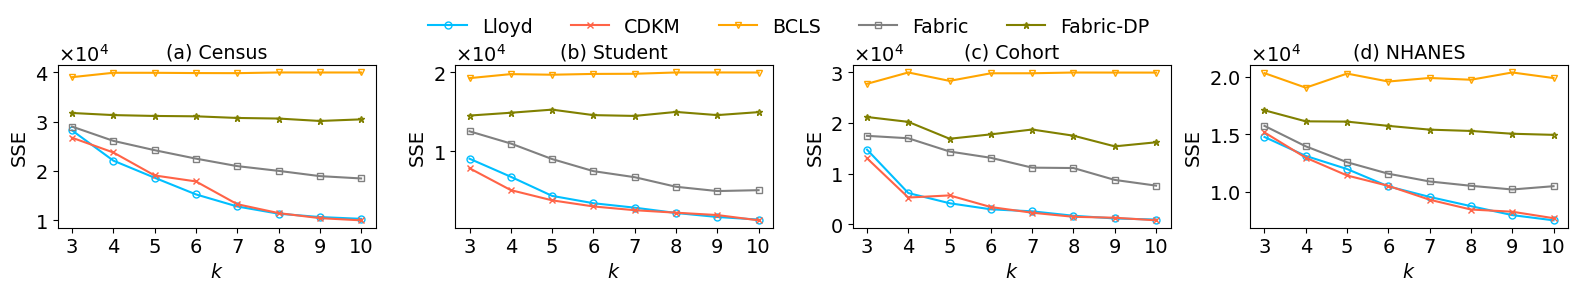

<Figure size 100x400 with 0 Axes>

In [107]:
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
marker = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
labels = ["Lloyd","CDKM","BCLS","Fabric","Fabric-DP", "x", "x", "x", "x"]
df = pd.read_csv('./fig1_1.csv')
df = df.to_numpy()


#fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,1,figsize=(14, 2))
fs = 14
fig, axs = plt.subplots(1, 4, figsize=(16, 2.8))
fig.tight_layout()
plt.figure(figsize=(1,4))
#axs[0,0].set_xlabel('X axis', fontsize = fs)
#axs[0,0].set_ylabel('y axis', fontsize = fs)
makesize = 5
linestyle1= '-.'
#3,2,6,10,1,9,4,8,11,5,7

def drawMapWithLabels(x, start_row, row_num, axs):
    for i in range(1, row_num + 1):
        linestyle='-'
        axs[x].plot(df[0], df[i + start_row],linestyle=linestyle, marker=marker[i-1],markersize=makesize, markerfacecolor='none',
                    markeredgewidth=markeredgewidth,color=colors[i-1],label=labels[i-1])

def drawMap(x, start_row, row_num, axs):
    for i in range(1, row_num + 1):
        linestyle='-'
        axs[x].plot(df[0],df[i + start_row],linestyle=linestyle, marker=marker[i-1],markersize=makesize, markerfacecolor='none',
                    markeredgewidth=markeredgewidth,color=colors[i-1])

row_num = 5
drawMapWithLabels(0, 0, row_num, axs)
drawMap(1, row_num * 1, row_num, axs)
drawMap(2, row_num * 2, row_num, axs)
drawMap(3, row_num * 3, row_num, axs)


fig.legend(loc='upper center',fontsize = fs*0.98, bbox_to_anchor=(0.5, 1.08),
          ncol=10, fancybox=False, shadow=False,frameon=False)


# titles = ["(a) Athlete","(b) Spanish","(c) Pricerunner","(d) Diabetes"]
titles = ["(a) Census","(b) Student","(c) Cohort","(d) NHANES"]

for i in range(0,4):
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))  
    axs[i].yaxis.set_major_formatter(formatter)
    axs[i].set_title(titles[i], fontsize = fs*0.98, pad=5)
    axs[i].set_ylabel('SSE', fontsize = fs)
    # axs[i].set_yscale("log")
    axs[i].set_xlabel("$k$", fontsize = fs*0.98)
    axs[i].set_xticks([1,2,3,4,5,6,7,8])
    axs[i].set_xticklabels(['3','4','5', '6','7','8','9','10'])

fig.tight_layout()
fig.subplots_adjust(wspace=0.25)
fig.subplots_adjust(hspace=0.5)
mpl.rcParams.update({'font.size': 14})
# fig.savefig("./SSE1.pdf", format="pdf", bbox_inches="tight")
fig.savefig("./SSE2.pdf", format="pdf", bbox_inches="tight")
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6036\4096524692.py:31: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[x].scatter(df[0], df[i + start_row], marker=marker[i-1], s=makesize, edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6036\4096524692.py:37: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[x].scatter(df[0], df[i + start_row], marker=marker[i-1], s=makesize, edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_6036\4096524692.py:37: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplo

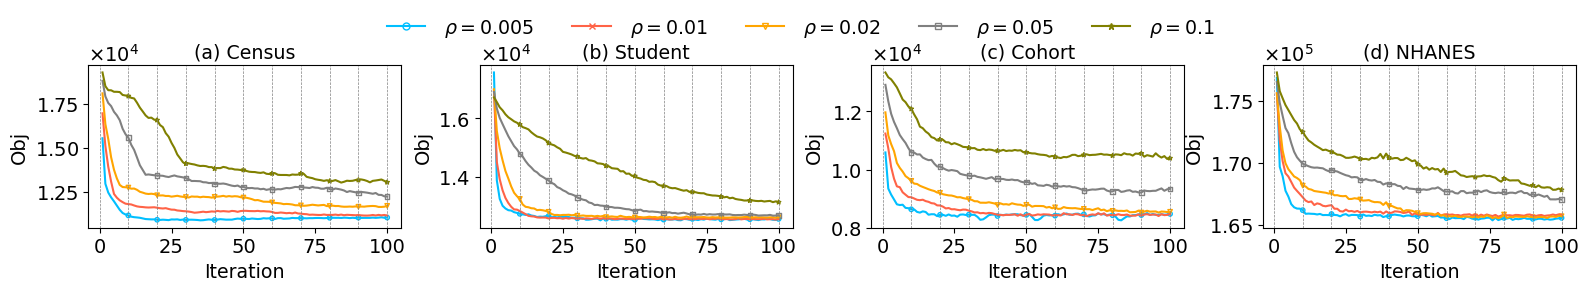

<Figure size 100x400 with 0 Axes>

In [6]:
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
marker = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
#labels = ["Sorting","AutoIS","Avg-Finding","Quantile","MOM","MaxMin","$R^{*}$","Quadtree","Grid","ZM","Learned ZM"]
labels = ["$\\rho=0.005$","$\\rho=0.01$","$\\rho=0.02$","$\\rho=0.05$","$\\rho=0.1$"]
df = pd.read_csv('./fig3.csv')
df = df.to_numpy()


#fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,1,figsize=(14, 2))
fs = 14
fig, axs = plt.subplots(1, 4, figsize=(16, 2.8))
fig.tight_layout()
plt.figure(figsize=(1,4))

# makesize = 0
makesize = np.zeros(len(df[0]))
makesize[np.mod(df[0], 10) == 0] = 10
linestyle1= '-.'

def smooth_data(data):
  window_length = 5  
  polyorder = 3
#   return savgol_filter(data, window_length, polyorder)
  return data

def drawMapWithLabels(x, start_row, row_num, axs):
    for i in range(1, row_num + 1):
        linestyle='-'
        axs[x].plot(df[0], smooth_data(df[i + start_row]), linestyle=linestyle, color=colors[i-1])
        axs[x].scatter(df[0], df[i + start_row], marker=marker[i-1], s=makesize, edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

def drawMap(x, start_row, row_num, axs):
    for i in range(1, row_num + 1):
        linestyle='-'
        axs[x].plot(df[0], smooth_data(df[i + start_row]), linestyle=linestyle, color=colors[i-1])
        axs[x].scatter(df[0], df[i + start_row], marker=marker[i-1], s=makesize, edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

row_num = 5
drawMapWithLabels(0, 0, row_num, axs)
drawMap(1, row_num * 1, row_num, axs)
drawMap(2, row_num * 2, row_num, axs)
drawMap(3, row_num * 3, row_num, axs)


handles = []

for idx, (color, marker) in enumerate(zip(colors, marker)):
    handle = mlines.Line2D([], [], linestyle='-', color=color, marker=marker,
                          markersize=5, markerfacecolor='none', markeredgewidth=markeredgewidth)
    handles.append(handle)

fig.legend(handles, labels, loc='upper center', fontsize=fs*0.98, ncol=5, bbox_to_anchor=(0.5, 1.08),
              fancybox=False, shadow=False, frameon=False, handlelength=2, handletextpad=1)


# titles = ["(a) Athlete","(b) Spanish","(c) Pricerunner","(d) Diabetes"]
titles = ["(a) Census","(b) Student","(c) Cohort","(d) NHANES"]

for i in range(0,4):
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3))  
    axs[i].yaxis.set_major_formatter(formatter)
    axs[i].set_title(titles[i], fontsize = fs*0.98, pad=5)
    axs[i].set_ylabel('Obj', fontsize = fs)
    # axs[i].set_yscale("log")
    axs[i].set_xlabel("Iteration", fontsize = fs*0.98)
    # axs[i].set_xticks([1,2,3,4,5,6,7,8])
    # axs[i].set_xticklabels(['3','4','5', '6','7','8','9','10'])

    for j in range(0, 11, 1):
        axs[i].axvline(x=j*10, color='gray', linestyle='--', linewidth=0.5)

fig.tight_layout()
fig.subplots_adjust(wspace=0.25)
fig.subplots_adjust(hspace=0.5)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./Loss_per_Dataset2.pdf", format="pdf", bbox_inches="tight")
# fig.savefig("./Loss_per_Dataset_dp1.pdf", format="pdf", bbox_inches="tight")
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_23560\729659224.py:31: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[x].scatter(df[0], df[i + start_row], marker=marker[i-1], s=makesize, edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23560\729659224.py:37: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  axs[x].scatter(df[0], df[i + start_row], marker=marker[i-1], s=makesize, edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_23560\729659224.py:37: UserWarning: You passed a edgecolor/edgecolors ('tomato') for an unfilled marker ('x').  Matplo

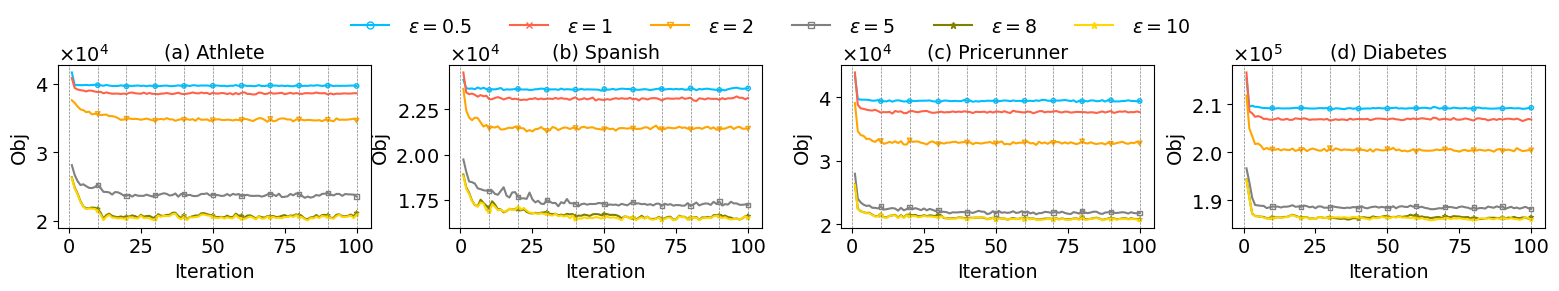

<Figure size 100x400 with 0 Axes>

In [8]:
colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
marker = ["o", "x", "v", "s", "*", "*", "x", "x", "x", "x"]
markeredgewidth = 1
#labels = ["Sorting","AutoIS","Avg-Finding","Quantile","MOM","MaxMin","$R^{*}$","Quadtree","Grid","ZM","Learned ZM"]
labels = ["$\\epsilon=0.5$","$\\epsilon=1$","$\\epsilon=2$","$\\epsilon=5$","$\\epsilon=8$","$\\epsilon=10$"]
df = pd.read_csv('./fig4.csv')
df = df.to_numpy()


#fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,1,figsize=(14, 2))
fs = 14
fig, axs = plt.subplots(1, 4, figsize=(16, 2.8))
fig.tight_layout()
plt.figure(figsize=(1,4))

# makesize = 0
makesize = np.zeros(len(df[0]))
makesize[np.mod(df[0], 10) == 0] = 10
linestyle1= '-.'

def smooth_data(data):
  window_length = 6 
  polyorder = 3  
#   return savgol_filter(data, window_length, polyorder)
  return data

def drawMapWithLabels(x, start_row, row_num, axs):
    for i in range(1, row_num + 1):
        linestyle='-'
        axs[x].plot(df[0], smooth_data(df[i + start_row]), linestyle=linestyle, color=colors[i-1])
        axs[x].scatter(df[0], df[i + start_row], marker=marker[i-1], s=makesize, edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

def drawMap(x, start_row, row_num, axs):
    for i in range(1, row_num + 1):
        linestyle='-'
        axs[x].plot(df[0], smooth_data(df[i + start_row]), linestyle=linestyle, color=colors[i-1])
        axs[x].scatter(df[0], df[i + start_row], marker=marker[i-1], s=makesize, edgecolors=colors[i-1], facecolors='none', linewidths=markeredgewidth)

row_num = 6
drawMapWithLabels(0, 0, row_num, axs)
drawMap(1, row_num * 1, row_num, axs)
drawMap(2, row_num * 2, row_num, axs)
drawMap(3, row_num * 3, row_num, axs)


handles = []

for idx, (color, marker) in enumerate(zip(colors, marker)):
    handle = mlines.Line2D([], [], linestyle='-', color=color, marker=marker,
                          markersize=5, markerfacecolor='none', markeredgewidth=markeredgewidth)
    handles.append(handle)

fig.legend(handles, labels, loc='upper center', fontsize=fs*0.98, ncol=10, bbox_to_anchor=(0.5, 1.08),
              fancybox=False, shadow=False, frameon=False, handlelength=2, handletextpad=1)

titles = ["(a) Athlete","(b) Spanish","(c) Pricerunner","(d) Diabetes"]
# titles = ["(a) Census","(b) Student","(c) Cohort","(d) NHANES"]

for i in range(0,4):
    formatter = mticker.ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((-3, 3)) 
    axs[i].yaxis.set_major_formatter(formatter)
    axs[i].set_title(titles[i], fontsize = fs*0.98, pad=5)
    axs[i].set_ylabel('Obj', fontsize = fs)
    # axs[i].set_yscale("log")
    axs[i].set_xlabel("Iteration", fontsize = fs*0.98)
    # axs[i].set_xticks([1,2,3,4,5,6,7,8])
    # axs[i].set_xticklabels(['3','4','5', '6','7','8','9','10'])


    for j in range(0, 11, 1):
        axs[i].axvline(x=j*10, color='gray', linestyle='--', linewidth=0.5)

fig.tight_layout()
fig.subplots_adjust(wspace=0.25)
fig.subplots_adjust(hspace=0.5)
mpl.rcParams.update({'font.size': 14})
fig.savefig("./Loss_per_Dataset_DP_epsilon1.pdf", format="pdf", bbox_inches="tight")
# fig.savefig("./Loss_per_Dataset_DP_epsilon2.pdf", format="pdf", bbox_inches="tight")
plt.show()

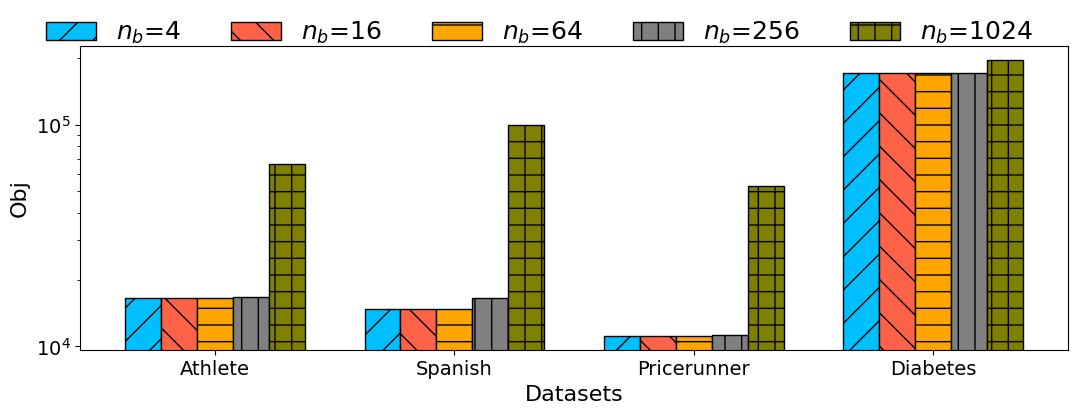

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.patches import Patch

# 读取CSV数据
df = pd.read_csv('./6blocksize.csv')

# 选择的数据集标签（注意大小写）
selected_datasets = ["Athlete", "Spanish", "Pricerunner", "Diabetes", "Census", "Student", "Cohort", "NHANES"]
selected_datasets = ["Athlete","Spanish","Pricerunner","Diabetes"]
# selected_datasets = ["Census","Student","Cohort","NHANES"]

nb_values = [4, 16, 64, 256, 1024]  


obj_values = {dataset: [] for dataset in selected_datasets}

# 获取每个数据集的 Obj 值
for dataset in selected_datasets:
    dataset_data = df[df['Dataset'] == dataset]
    obj_values[dataset] = [dataset_data[dataset_data['nb'] == nb]['Obj'].values[0] for nb in nb_values]

width = 0.15  
x = np.arange(len(selected_datasets))  


fig, ax = plt.subplots(figsize=(11, 4))


colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
hatches = ['/', '\\', '-', '|', '+']  # Valid hatch patterns


bars = []
for i, dataset in enumerate(selected_datasets):
    for j, nb in enumerate(nb_values):
        bar = ax.bar(x[i] + width * j, obj_values[dataset][j], width,edgecolor='black', color=colors[j], label=f'nb={nb}' if i == 0 else "", hatch=hatches[j])
        bars.append(bar)


# ax.set_title("Comparison of Obj across Datasets and nb values", fontsize=16)
ax.set_xlabel("Datasets", fontsize=16)
ax.set_ylabel("Obj", fontsize=16)
ax.set_xticks(x + width * 2) 
ax.set_xticklabels(selected_datasets)

handles = []

    
legend_elements = [
    Patch(
        facecolor=colors[i],
        label=f'$n_b$={nb_values[i]}',
        hatch=hatches[i % len(hatches)],
        edgecolor='black'  
    ) 
    for i, method in enumerate(nb_values)
]



# ax.legend(handles=handles, loc="upper left", fontsize=18, frameon=False)
    
legend = fig.legend(
    handles=legend_elements, 
    loc='upper center', 
    ncol=len(nb_values), 
    bbox_to_anchor=(0.5, 1.07), 
    fontsize=18, 
    frameon=False,  
)
    

# ax.set_ylim(0, max([max(obj_values[dataset]) for dataset in selected_datasets]) * 1.1)
ax.set_yscale('log')  

# ax.grid(True, linestyle='--', alpha=0.7)

fig.tight_layout()


fig.savefig("./Obj6blocksize.pdf", format="pdf", bbox_inches="tight")


plt.show()


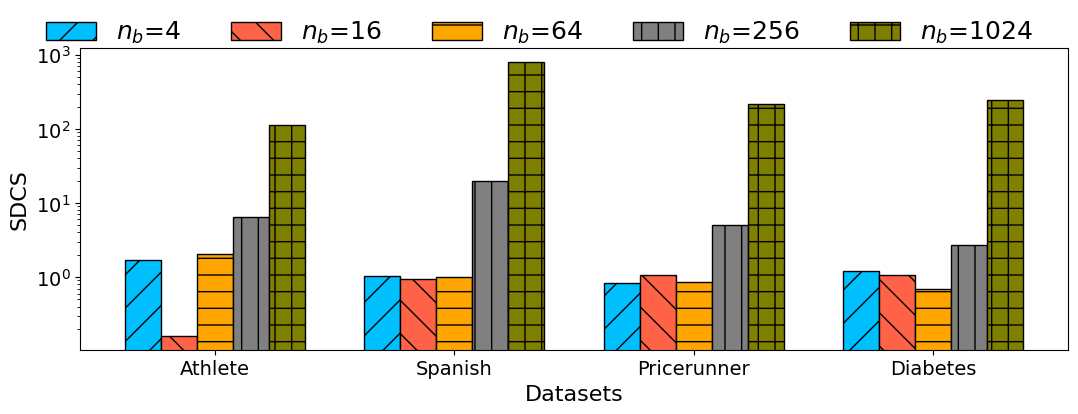

In [89]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.patches import Patch


df = pd.read_csv('./6blocksize_1.csv')


selected_datasets = ["Athlete", "Spanish", "Pricerunner", "Diabetes", "Census", "Student", "Cohort", "NHANES"]
selected_datasets = ["Athlete","Spanish","Pricerunner","Diabetes"]
# selected_datasets = ["Census","Student","Cohort","NHANES"]

nb_values = [4, 16, 64, 256, 1024] 

obj_values = {dataset: [] for dataset in selected_datasets}


for dataset in selected_datasets:
    dataset_data = df[df['Dataset'] == dataset]
    obj_values[dataset] = [dataset_data[dataset_data['nb'] == nb]['SDCS'].values[0] for nb in nb_values]


width = 0.15  
x = np.arange(len(selected_datasets))  


fig, ax = plt.subplots(figsize=(11, 4))

colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
hatches = ['/', '\\', '-', '|', '+']  # Valid hatch patterns

bars = []
for i, dataset in enumerate(selected_datasets):
    for j, nb in enumerate(nb_values):
        bar = ax.bar(x[i] + width * j, obj_values[dataset][j], width,edgecolor='black', color=colors[j], label=f'nb={nb}' if i == 0 else "", hatch=hatches[j])
        bars.append(bar)


# ax.set_title("Comparison of Obj across Datasets and nb values", fontsize=16)
ax.set_xlabel("Datasets", fontsize=16)
ax.set_ylabel("SDCS", fontsize=16)
ax.set_xticks(x + width * 2)  
ax.set_xticklabels(selected_datasets)

handles = []

    
legend_elements = [
    Patch(
        facecolor=colors[i],
        label=f'$n_b$={nb_values[i]}',
        hatch=hatches[i % len(hatches)],
        edgecolor='black'  
    ) 
    for i, method in enumerate(nb_values)
]


# ax.legend(handles=handles, loc="upper left", fontsize=18, frameon=False)
    
legend = fig.legend(
    handles=legend_elements, 
    loc='upper center', 
    ncol=len(nb_values), 
    bbox_to_anchor=(0.5, 1.07), 
    fontsize=18, 
    frameon=False,  
)
    

# ax.set_ylim(0, max([max(obj_values[dataset]) for dataset in selected_datasets]) * 1.1)
ax.set_yscale('log')  
# ax.grid(True, linestyle='--', alpha=0.7)

fig.tight_layout()

fig.savefig("./SDCS6blocksize.pdf", format="pdf", bbox_inches="tight")

plt.show()


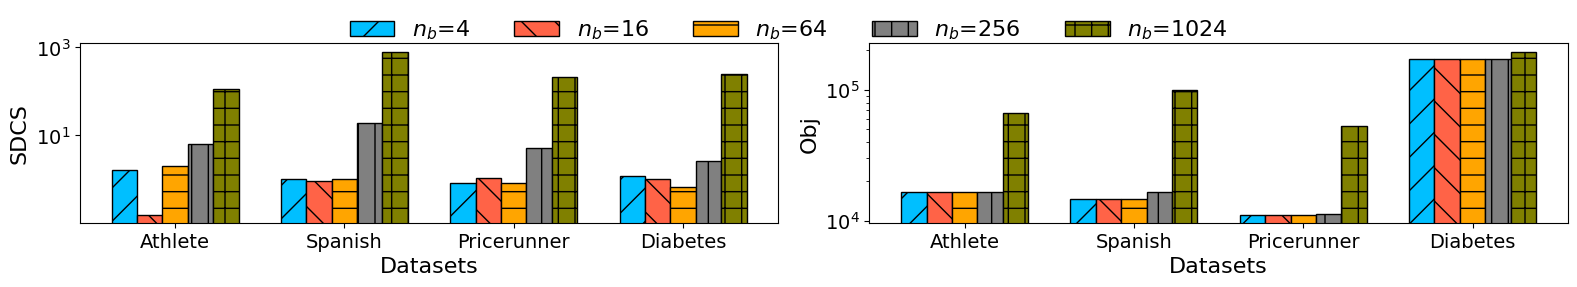

In [104]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

df_obj = pd.read_csv('./6blocksize.csv')
df_sdc = pd.read_csv('./6blocksize_1.csv')

selected_datasets = ["Athlete", "Spanish", "Pricerunner", "Diabetes"]
nb_values = [4, 16, 64, 256, 1024]  

obj_values = {dataset: [] for dataset in selected_datasets}
sdc_values = {dataset: [] for dataset in selected_datasets}

for dataset in selected_datasets:
    dataset_data_obj = df_obj[df_obj['Dataset'] == dataset]
    obj_values[dataset] = [dataset_data_obj[dataset_data_obj['nb'] == nb]['Obj'].values[0] for nb in nb_values]

    dataset_data_sdc = df_sdc[df_sdc['Dataset'] == dataset]
    sdc_values[dataset] = [dataset_data_sdc[dataset_data_sdc['nb'] == nb]['SDCS'].values[0] for nb in nb_values]

width = 0.15  
x = np.arange(len(selected_datasets)) 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 2.8)) 

colors = ['deepskyblue', 'tomato', 'orange', 'grey', 'olive', 'gold', 'green', 'red', 'black', 'brown']
hatches = ['/', '\\', '-', '|', '+']  # Valid hatch patterns

for i, dataset in enumerate(selected_datasets):
    for j, nb in enumerate(nb_values):
        ax1.bar(x[i] + width * j, sdc_values[dataset][j], width, edgecolor='black', color=colors[j], label=f'nb={nb}' if i == 0 else "", hatch=hatches[j])

ax1.set_xlabel("Datasets", fontsize=16)
ax1.set_ylabel("SDCS", fontsize=16)
ax1.set_xticks(x + width * 2) 
ax1.set_xticklabels(selected_datasets)
ax1.set_yscale('log')
# ax1.set_title("SDCS of Datasets at varying $n_b$", fontsize=16)

for i, dataset in enumerate(selected_datasets):
    for j, nb in enumerate(nb_values):
        ax2.bar(x[i] + width * j, obj_values[dataset][j], width, edgecolor='black', color=colors[j], label=f'nb={nb}' if i == 0 else "", hatch=hatches[j])

ax2.set_xlabel("Datasets", fontsize=16)
ax2.set_ylabel("Obj", fontsize=16)
ax2.set_xticks(x + width * 2) 
ax2.set_xticklabels(selected_datasets)
ax2.set_yscale('log')
# ax2.set_title("OBJ of Datasets at varying $n_b$", fontsize=16)

legend_elements = [
    Patch(facecolor=colors[i], label=f'$n_b$={nb_values[i]}', hatch=hatches[i % len(hatches)], edgecolor='black') 
    for i, nb in enumerate(nb_values)
]

fig.legend(handles=legend_elements, loc='upper center', ncol=len(nb_values), bbox_to_anchor=(0.5, 1.07), fontsize=16, frameon=False)

fig.tight_layout()

fig.savefig("./SDCS_and_Obj_6blocksize.pdf", format="pdf", bbox_inches="tight")

plt.show()
